# Klasifikasi Tingkat Kekeringan Dramaga (1980 sampai 2024)
## Tahap 03: Modelling & Evaluasi Benchmark

**Kata Kunci Penerapan:**
- **Temporal Split**: Menghindari data leakage dengan membagi data berdasarkan urutan waktu.
- **Multi-scale Features**: Menggunakan jendela 30, 90, dan 180 hari untuk menangkap memori iklim.
- **Seasonality Encoding**: Menggunakan fungsi trigonometri untuk fitur bulan.
- **SMOTE**: Menangani ketidakseimbangan kelas pada data training.

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from dramaga_drought import (
    load_featured_dataset,
    load_model_splits,
    plot_classification_confusion_matrix,
    plot_feature_importance,
    plot_risk_forecast,
    train_30d_risk_model,
    train_classification_models,
)

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
})
sns.set_theme(style='whitegrid', palette='muted')


## 1. Loading Output Feature Engineering

Notebook ini memakai output final dari `notebooks/02_feature_engineering.ipynb`: `dataset_featured_dramaga.csv`. Split train dan test dibuat secara temporal lewat fungsi `load_model_splits`, sehingga tidak perlu menyimpan file `X_train`, `X_test`, `y_train`, atau `y_test`.


In [ ]:
splits = load_model_splits()
X_train = splits['X_train']
X_test = splits['X_test']
y_train = splits['y_train']
y_test = splits['y_test']
train_df = splits['train_df']
test_df_split = splits['test_df']
df_full = load_featured_dataset()

features = X_train.columns.tolist()
target = 'drought_class'

print(f'Features: {features}')
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'y_train distribution:\n{y_train.value_counts().sort_index()}')
print(f'\ny_test distribution:\n{y_test.value_counts().sort_index()}')

## 2. Preprocessing (Scaling & SMOTE)
Scaling dengan StandardScaler dan oversampling kelas minoritas dengan SMOTE.

In [25]:
classification_artifacts = train_classification_models(X_train, y_train, X_test, y_test)
models = classification_artifacts['models']
results = classification_artifacts['results']

print(f'After SMOTE: {classification_artifacts["x_train_resampled_shape"]}')
print(f'Testing set: {classification_artifacts["x_test_scaled_shape"]}')

Training set size: (35024, 14)
Testing set size: (3252, 14)


## 3. Benchmark Models
Kami membandingkan empat algoritma: Random Forest, XGBoost, LightGBM, dan Multi-Layer Perceptron (Neural Network).

In [26]:
for name, result in results.items():
    print(f'\n{name} Results')
    print(f"Accuracy         : {result['accuracy']:.4f}")
    print(f"F1 Score (Macro) : {result['macro_f1']:.4f}\n")
    print('Classification Report:')
    print(result['classification_report'])
    print('Confusion Matrix:')
    print(result['confusion_matrix'])

▶ Training & Evaluating Random Forest...

Random Forest Results
Accuracy         : 0.8875
F1 Score (Macro) : 0.7936

Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.97      0.97      1998
        Mild       0.78      0.73      0.75       503
    Moderate       0.73      0.87      0.79       538
      Severe       0.79      0.57      0.66       213

    accuracy                           0.89      3252
   macro avg       0.82      0.78      0.79      3252
weighted avg       0.89      0.89      0.89      3252

Confusion Matrix:
[[1930   29   24   15]
 [  43  367   78   15]
 [   3   64  468    3]
 [   7   10   75  121]]


▶ Training & Evaluating XGBoost...

XGBoost Results
Accuracy         : 0.9533
F1 Score (Macro) : 0.9192

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      1998
        Mild       0.90      0.89      0.89       503
    Moderate       0.

## 4. Visualisasi & Analisa
Kami fokus pada hasil model terbaik (**LightGBM**) untuk dianalisa lebih dalam.

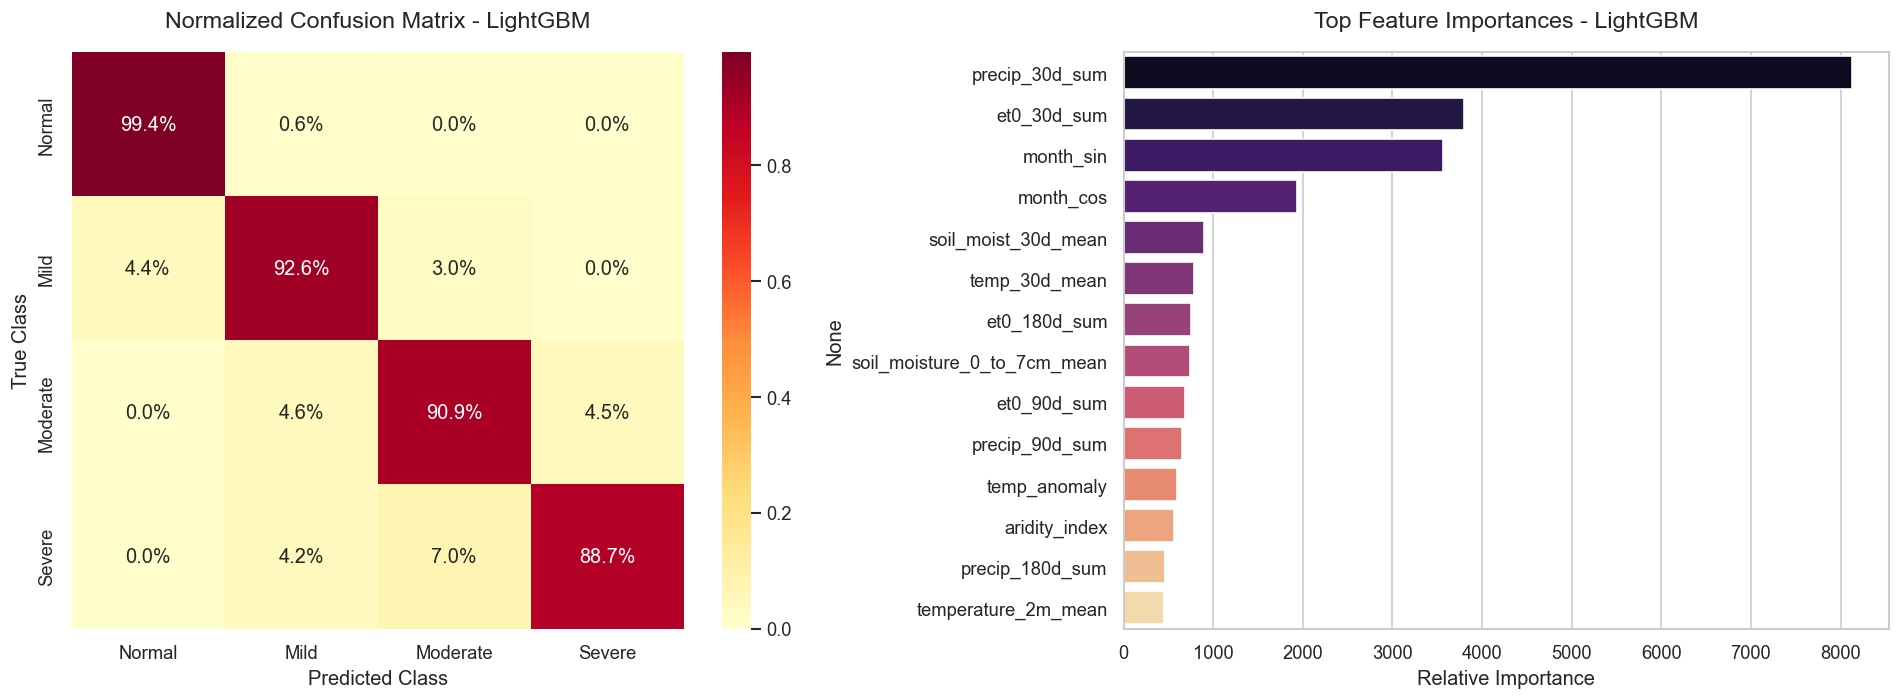

In [27]:
best_model_name = "LightGBM"
best_model = results[best_model_name]['model']
y_pred = results[best_model_name]['y_pred']

plot_classification_confusion_matrix(results[best_model_name]['confusion_matrix'])
plt.show()

plot_feature_importance(best_model, features)
plt.show()

### Visualisasi Prediksi vs Aktual (Time-Series)
Bagian ini menunjukkan bagaimana model memprediksi fluktuasi kekeringan pada periode testing.

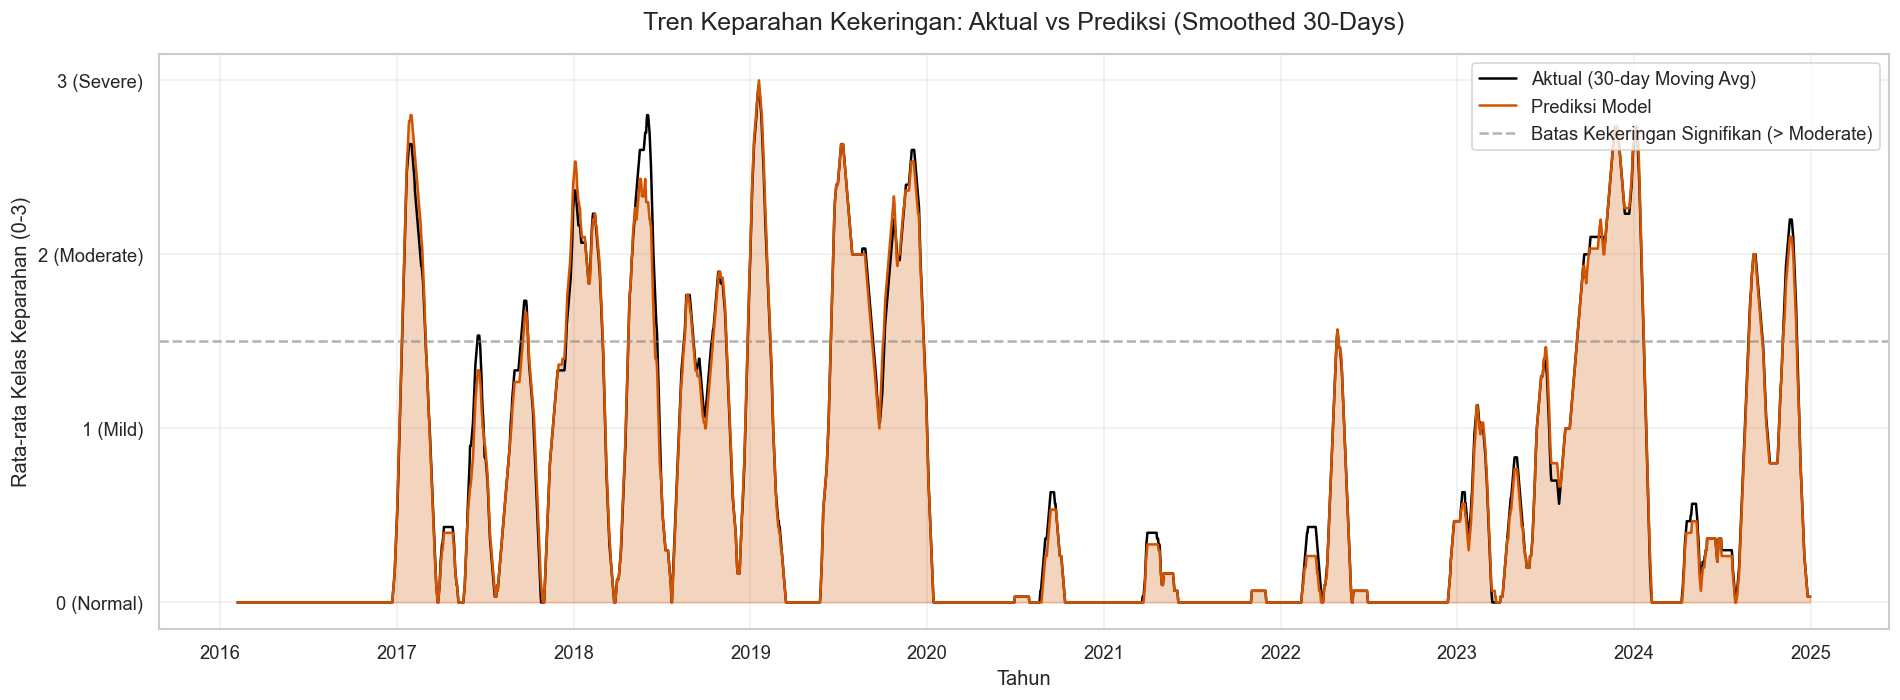

In [32]:
import matplotlib.pyplot as plt

# Reconstruct test period from full dataset
split_idx = int(len(df_full) * 0.8)
test_df = df_full.iloc[split_idx:].copy()
test_df['Predicted'] = y_pred

smoothed_actual = test_df['drought_class'].rolling(window=30, min_periods=1).mean()
smoothed_pred = test_df['Predicted'].rolling(window=30, min_periods=1).mean()

plt.figure(figsize=(16, 6))
plt.plot(test_df['date'], smoothed_actual, label='Aktual (30-day Moving Avg)', color='black', linewidth=1.5)
plt.plot(test_df['date'], smoothed_pred, label='Prediksi Model', color='#d35400', linewidth=1.5)
plt.fill_between(test_df['date'], 0, smoothed_pred, color='#d35400', alpha=0.25)
plt.axhline(y=1.5, color='gray', linestyle='--', alpha=0.6, label='Batas Kekeringan Signifikan (> Moderate)')

plt.title('Tren Keparahan Kekeringan: Aktual vs Prediksi (Smoothed 30-Days)', fontsize=15, pad=15)
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Rata-rata Kelas Keparahan (0-3)', fontsize=12)
plt.yticks([0, 1, 2, 3], ['0 (Normal)', '1 (Ringan)', '2 (Sedang)', '3 (Parah)'])
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

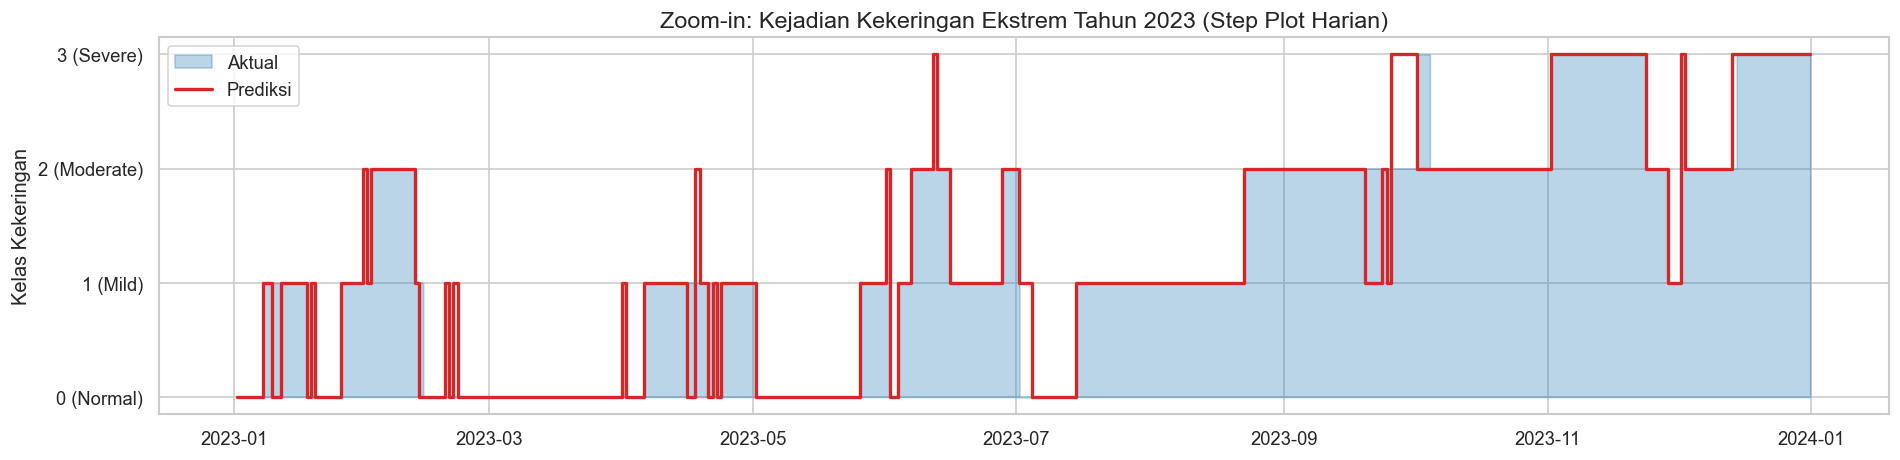

In [33]:
# Zoom-in pada tahun 2023
zoom_df = test_df[test_df['date'].dt.year == 2023]

if not zoom_df.empty:
    plt.figure(figsize=(16, 4))
    plt.fill_between(zoom_df['date'], 0, zoom_df['drought_class'], step='post', color='tab:blue', alpha=0.3, label='Aktual')
    plt.step(zoom_df['date'], zoom_df['Predicted'], where='post', color='tab:red', linewidth=2, label='Prediksi')
    plt.title('Zoom-in: Kejadian Kekeringan Tahun 2023 (Step Plot Harian)', fontsize=14)
    plt.ylabel('Kelas Kekeringan')
    plt.yticks([0, 1, 2, 3], ['0 (Normal)', '1 (Ringan)', '2 (Sedang)', '3 (Parah)'])
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

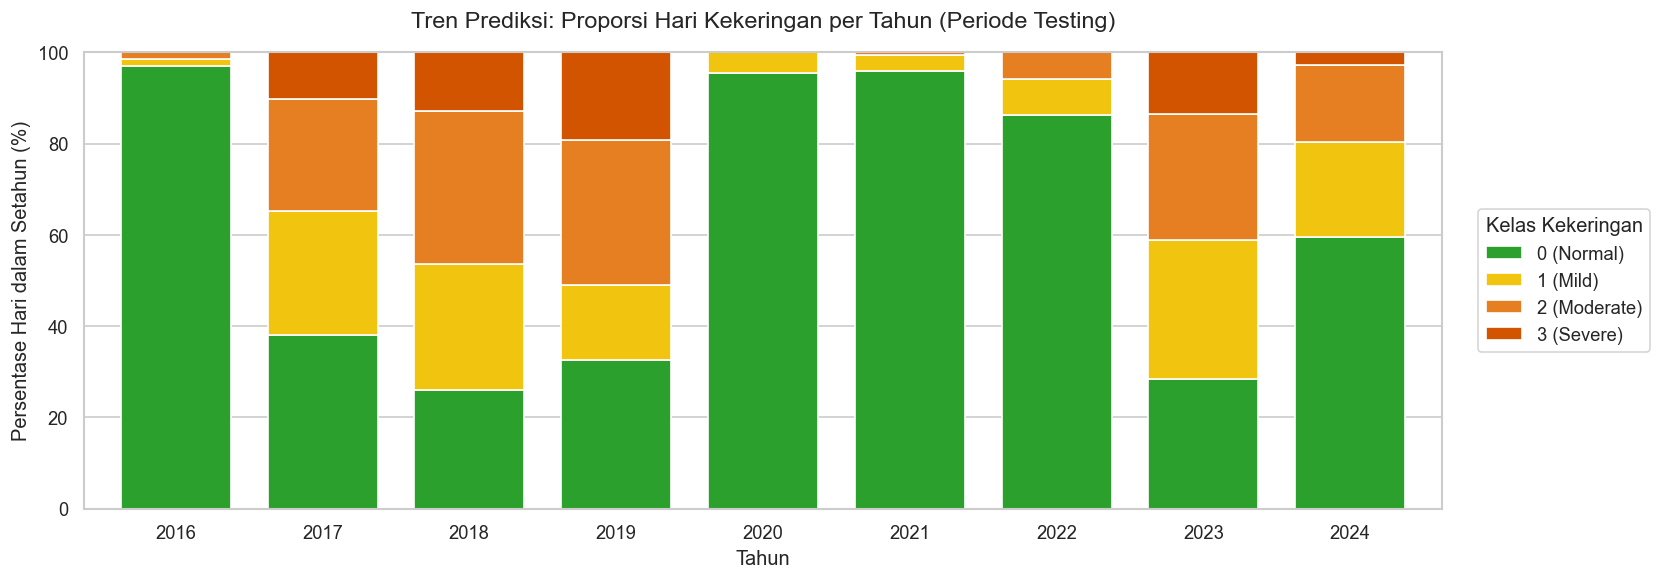

In [ ]:
# Proporsi Kelas Kekeringan per Tahun (Stacked Bar Chart)
yearly_dist = test_df.groupby([test_df['date'].dt.year, 'Predicted']).size().unstack(fill_value=0)

yearly_dist_pct = yearly_dist.div(yearly_dist.sum(axis=1), axis=0) * 100

colors = ['#2ca02c', '#f1c40f', '#e67e22', '#d35400']
ax = yearly_dist_pct.plot(kind='bar', stacked=True, color=colors, figsize=(14, 5), width=0.75)

plt.title('Tren Prediksi: Proporsi Hari Kekeringan per Tahun (Periode Testing)', fontsize=14, pad=15)
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Persentase Hari dalam Setahun (%)', fontsize=12)
plt.legend(['0 (Normal)', '1 (Ringan)', '2 (Sedang)', '3 (Parah)'],
           loc='center left', bbox_to_anchor=(1.02, 0.5), title='Kelas Kekeringan')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Forecasting Risiko Kekeringan 30 Hari ke Depan

Untuk horizon yang lebih jauh, target yang lebih stabil dan berguna adalah **apakah akan terjadi kekeringan minimal sedang dalam 30 hari ke depan**. Target bernilai 1 jika ada hari pada jendela H+1 sampai H+30 dengan `spei_30d <= -1.0`, dan 0 jika tidak ada.

Fitur forecast boleh memakai `spei_30d`, `spei_90d`, `spei_180d`, dan `wb_*` pada hari ini karena nilai tersebut sudah diketahui saat prediksi dibuat. Threshold probabilitas dipilih dari validation split temporal di dalam training set, lalu baru dievaluasi pada test set.


In [ ]:
forecast_horizon = 30
forecast_artifacts = train_30d_risk_model(df_full, horizon=forecast_horizon)
forecast_test = forecast_artifacts['test_df']
forecast_target = forecast_artifacts['target']
best_threshold = forecast_artifacts['metrics']['validation_threshold']

print(f'Forecast target: risiko kekeringan minimal sedang dalam {forecast_horizon} hari ke depan')
print(f"Forecast features: {len(forecast_artifacts['features'])} fitur")
for metric_name, metric_value in forecast_artifacts['metrics'].items():
    print(f'{metric_name}: {metric_value:.4f}')

print('\n30-Day Drought Risk Classification Report:')
print(forecast_artifacts['classification_report'])


In [ ]:
plot_risk_forecast(forecast_test, forecast_target, best_threshold, horizon=forecast_horizon)
plt.show()
